# Script 1 — Iris: load, clean, and visualize

**Iris** is a dataset of 150 measurements of iris flowers, collected by botanist Edgar
Anderson in 1935. Each row is one individual flower. There are three species, 50 flowers
each: *setosa*, *versicolor*, and *virginica*.

Every flower is described by four measurements, all in **centimeters**:

| column | what it physically measures |
|---|---|
| sepal length | the long axis of a sepal — the green leaf-like flap that protected the bud |
| sepal width  | the short axis of that same sepal |
| petal length | the long axis of a petal — the colored show part of the flower |
| petal width  | the short axis of that petal |

The goal here is the basic data pipeline: **load → clean → plot**.

In [1]:
# Step 1: load the Iris data set into a pandas DataFrame.
import pandas as pd
import matplotlib.pyplot as plt

from cs156.data import iris

# iris() hands back four things: the 150x4 grid of measurements (X), a species code
# 0/1/2 for each flower (y), the names of the four columns, and the names of the
# three species. Iris ships inside scikit-learn, so nothing is downloaded.
X, y, feature_names, target_names = iris()

# A DataFrame is a spreadsheet in memory: named columns, one row per flower.
df = pd.DataFrame(X, columns=feature_names)

# y holds 0/1/2. Translate those codes into readable species names.
df["species"] = [target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Look at the data before touching it

Always check the shape and the ranges first — that is how you catch a bad load
(wrong column count, values in the wrong units, missing entries).

In [2]:
# Step 1b: sanity-check what we loaded.
print("rows, columns:", df.shape)          # expect (150, 5): 4 measurements + species
print("missing values:", df.isna().sum().sum())   # Iris is complete, so expect 0
print()
print(df["species"].value_counts())        # expect 50 of each species

# .describe() prints min/max/mean per column. All four should sit in a plausible
# centimeter range for a flower (roughly 0-8 cm), not millimeters or inches.
df.describe().round(2)

rows, columns: (150, 5)
missing values: 0

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


### Step 2: clean — drop every row where sepal length is greater than 5 cm

"Cleaning" here just means **filtering**: we keep only the flowers whose sepals are
5 cm or shorter, and throw the rest of the rows away.

The comparison `df["sepal length (cm)"] <= 5` produces one True/False per flower.
Handing that column of booleans back to the DataFrame keeps only the True rows —
this is called *boolean masking*, and it is the standard pandas way to filter.

In [3]:
# Step 2: keep only flowers with sepal length <= 5 cm (i.e. drop the ones > 5 cm).
SEPAL_LEN = "sepal length (cm)"

keep = df[SEPAL_LEN] <= 5      # a True/False flag for each of the 150 flowers
small = df[keep].copy()        # .copy() so later edits don't warn about a view

print(f"kept {len(small)} of {len(df)} flowers ({len(small) / len(df):.0%})")
print(f"sepal length now ranges {small[SEPAL_LEN].min():.1f}-{small[SEPAL_LEN].max():.1f} cm")
print()
print(small["species"].value_counts())

kept 32 of 150 flowers (21%)
sepal length now ranges 4.3-5.0 cm

species
setosa        28
versicolor     3
virginica      1
Name: count, dtype: int64


**What that filter actually accomplished — and why it is worth noticing.**

We asked a question about *size* and got back an answer about *species*. Of the 32
surviving flowers, 28 are setosa and only 4 are versicolor or virginica. That is not a
coincidence: setosa is simply the smaller flower, so a 5 cm sepal cutoff is very nearly
a "keep the setosas" rule in disguise.

This is a real hazard in a data pipeline. A filter that looks purely mechanical can
quietly delete an entire class from your data, and a model trained on what is left will
never see the classes you dropped. The plot below keeps both the before and after so
you can see the bite the filter took.

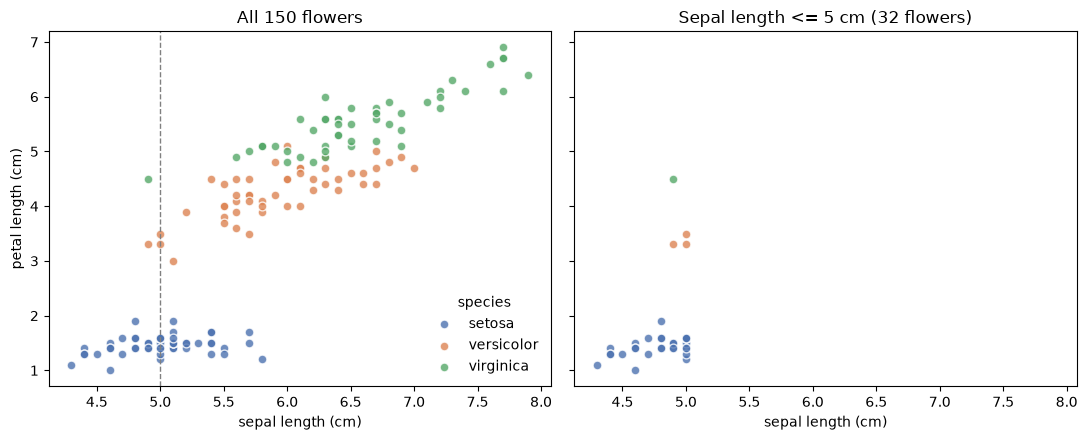

In [4]:
# Step 3: scatter plot petal length vs sepal length, one color per species.
# Each dot is one flower: x = how long its sepal is, y = how long its petal is.
colors = {"setosa": "#4C72B0", "versicolor": "#DD8452", "virginica": "#55A868"}

fig, (ax_all, ax_small) = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, data, title in [(ax_all, df, "All 150 flowers"),
                        (ax_small, small, f"Sepal length <= 5 cm ({len(small)} flowers)")]:
    for name, group in data.groupby("species"):
        ax.scatter(group[SEPAL_LEN], group["petal length (cm)"],
                   c=colors[name], label=name, s=40, alpha=0.8, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("sepal length (cm)")

ax_all.set_ylabel("petal length (cm)")
ax_all.axvline(5, color="gray", ls="--", lw=1)   # the cutoff we filtered on
ax_all.legend(title="species", frameon=False)
plt.tight_layout()
# Save a copy for the session README, so the plot is visible without running anything.
fig.savefig("assets/3.1-iris-scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the plot.** Both axes are centimeters, so the picture is literally a scale
drawing of flower proportions.

- The left panel shows the whole dataset. Setosa (blue) sits alone in the bottom-left:
  short sepals *and* very short petals, with a clear empty gap between it and the others.
  Versicolor and virginica overlap each other along a shared upward trend — longer sepals
  come with longer petals.
- The dashed line at x = 5 is the cutoff. Everything to its right gets deleted.
- The right panel is what survives, and it is almost entirely the blue cluster.

The takeaway for a classifier: setosa is separable from the other two by petal length
alone, while versicolor and virginica are not cleanly separable in these two dimensions.
That gap is why Iris shows up in every intro ML course.